In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
import os
import torch
import yaml
from helpers.data_transforms import  load_in_data


plt.style.use("../science.mplstyle")

In [2]:
from helpers.plotting import plot_hists_1d, plot_corner_hist_2d

In [3]:


BIN_BOUND = 5
NUM_BINS = 100
NUM_FEATURES = 5



working_dir = "/pscratch/sd/r/rmastand/muon_collider"

In [4]:
data_dict = {}

for col_name in ["OuterTrackerBarrelCollection", "InnerTrackerBarrelCollection", "VertexBarrelCollection"]:
    data_dict[col_name], _, feature_labels = load_in_data([col_name], "xy", working_dir, 1)
        

bins_dict = {
    0: np.linspace(-20, 0, NUM_BINS),
    1: np.linspace(0, 1500, NUM_BINS),
    2: np.linspace(-4, 4, NUM_BINS),
    3: np.linspace(-1500, 1500, NUM_BINS),
    4: np.linspace(-5, 25, NUM_BINS),
}

(<Figure size 2160x360 with 5 Axes>,
 array([<Axes: xlabel='log($E$) [Gev]', ylabel='Density'>,
        <Axes: xlabel='$x$'>, <Axes: xlabel='$y$'>, <Axes: xlabel='$z$'>,
        <Axes: xlabel='$t$ [s]'>], dtype=object))

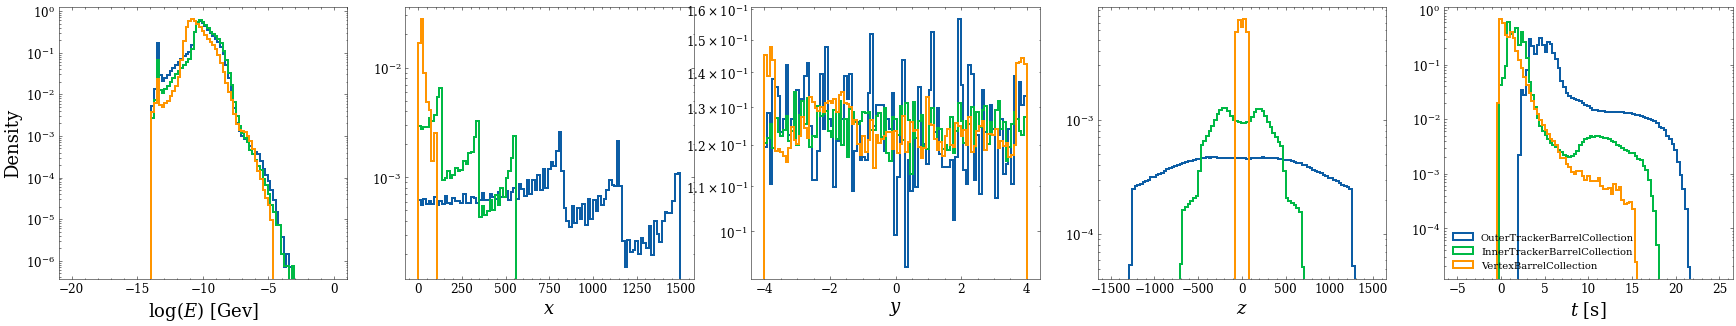

In [5]:

plot_hists_1d(data_dict, bins_dict, log_dims=[], labels=feature_labels)

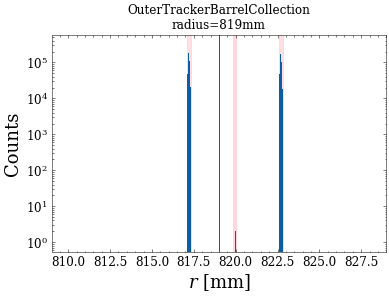

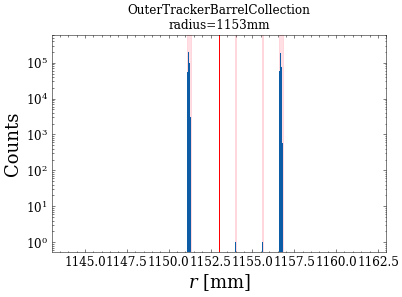

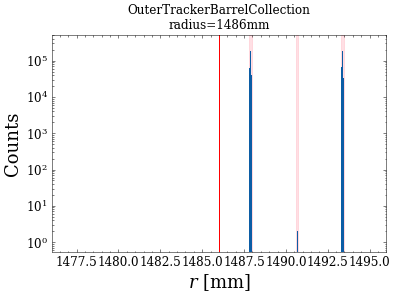

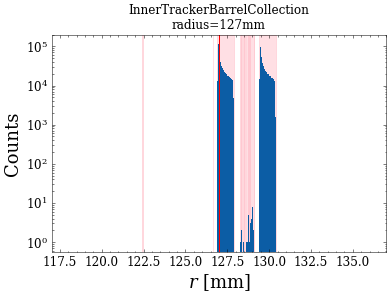

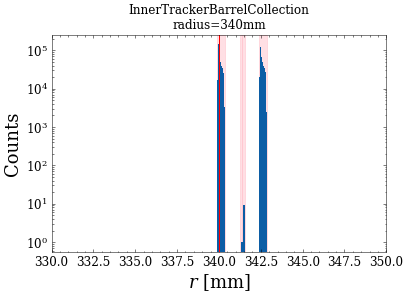

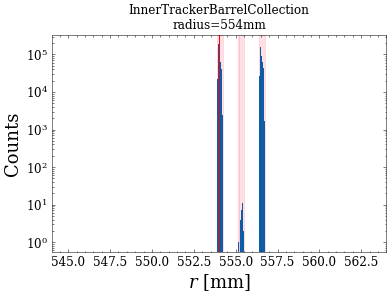

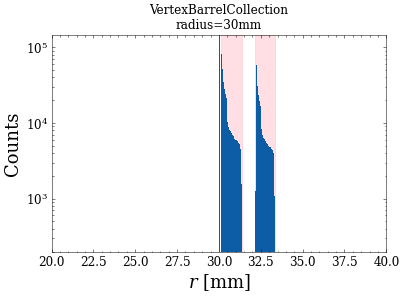

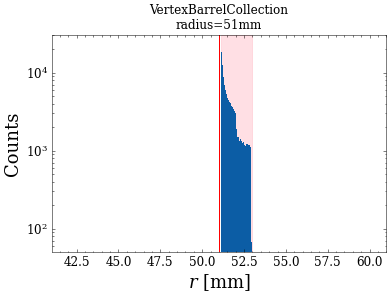

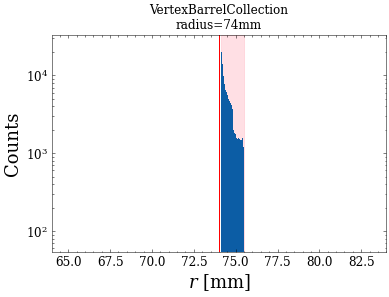

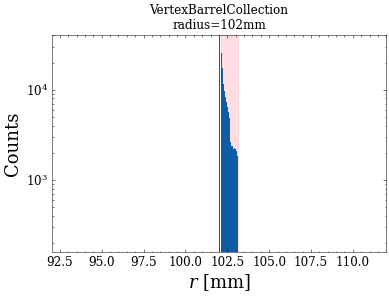

In [6]:
radii = {
    "OuterTrackerBarrelCollection": [819, 1153, 1486],
    "InnerTrackerBarrelCollection": [127, 340, 554],
    "VertexBarrelCollection": [30, 51, 74, 102],
}


mask_definitions = {
    col_name: { 
        r: { 
            "lower_bounds":[],
            "upper_bounds":[],
            
           } for r in radii[col_name]
}              
   for col_name in data_dict.keys() 
                   }

for col_name in data_dict.keys():

    r = np.sqrt(data_dict[col_name][:,1]**2 + data_dict[col_name][:,2]**2)
    
    for radius in radii[col_name]:

        bins = np.linspace(radius - 10, radius + 10, 1000)
        
        hist, bin_edges = np.histogram(r, bins)

        for i in range(len(hist)-1):
            if hist[i] == 0 and hist[i+1] > 0:
                mask_definitions[col_name][radius]["lower_bounds"].append(bin_edges[i])
            if hist[i] > 0 and hist[i+1] == 0:
                mask_definitions[col_name][radius]["upper_bounds"].append(bin_edges[i+1])

    
        plt.figure()
        for j in range(len(mask_definitions[col_name][radius]["lower_bounds"])):
            plt.axvspan(mask_definitions[col_name][radius]["lower_bounds"][j], mask_definitions[col_name][radius]["upper_bounds"][j], alpha = 0.5, color = "pink")
            
        plt.hist(r, bins = bins)
        plt.xlim([radius - 10, radius + 10])
        plt.axvline(radius, color = "r")

        plt.title(f"{col_name}\nradius={radius}mm")
        plt.yscale("log")
        plt.xlabel("$r$ [mm]")
        plt.ylabel("Counts")
        plt.show()

In [7]:
with open("mask_definitions.pkl", "wb") as ofile:
    pickle.dump(mask_definitions, ofile)

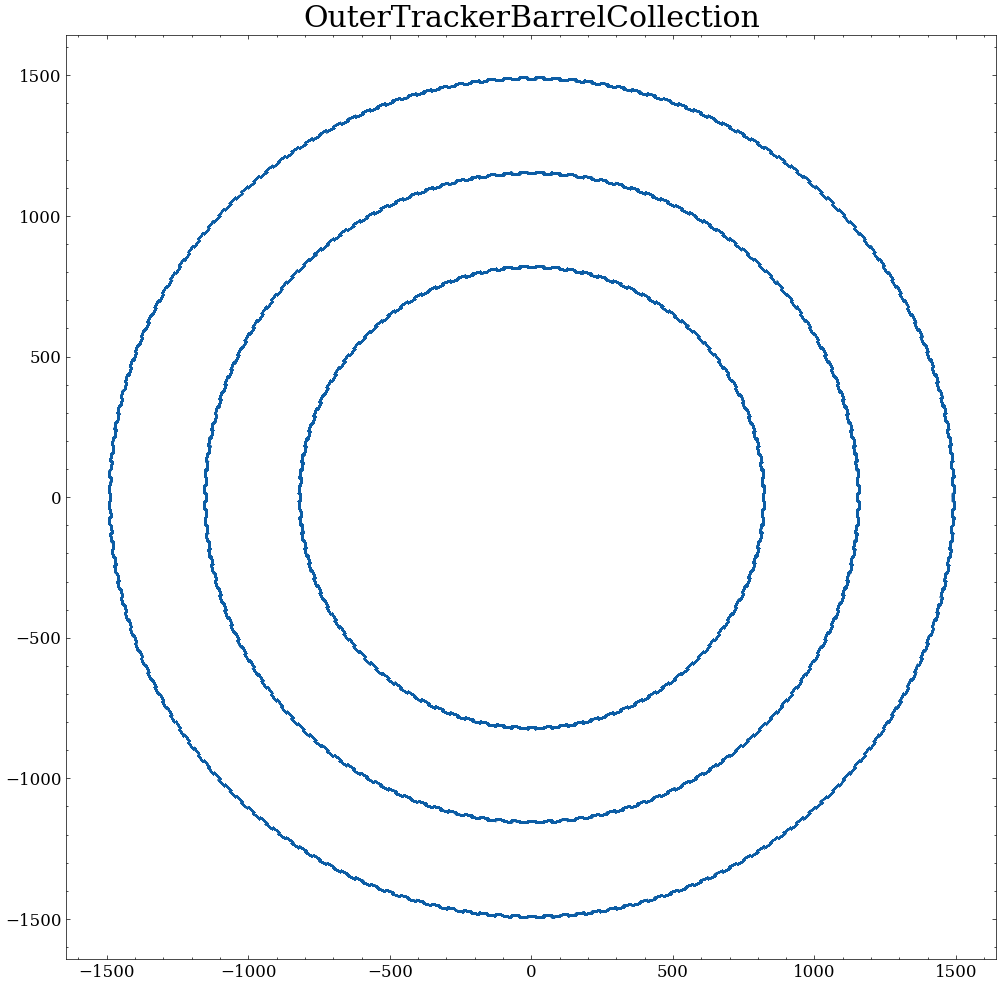

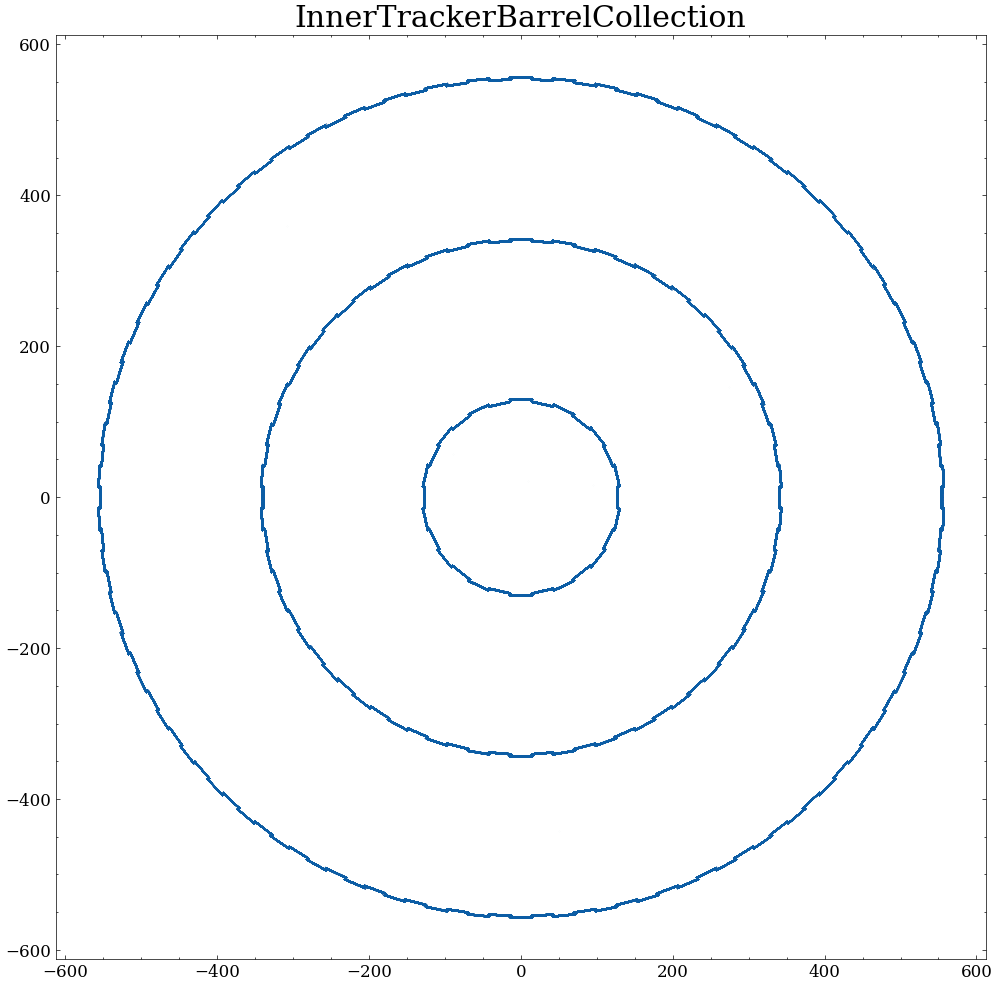

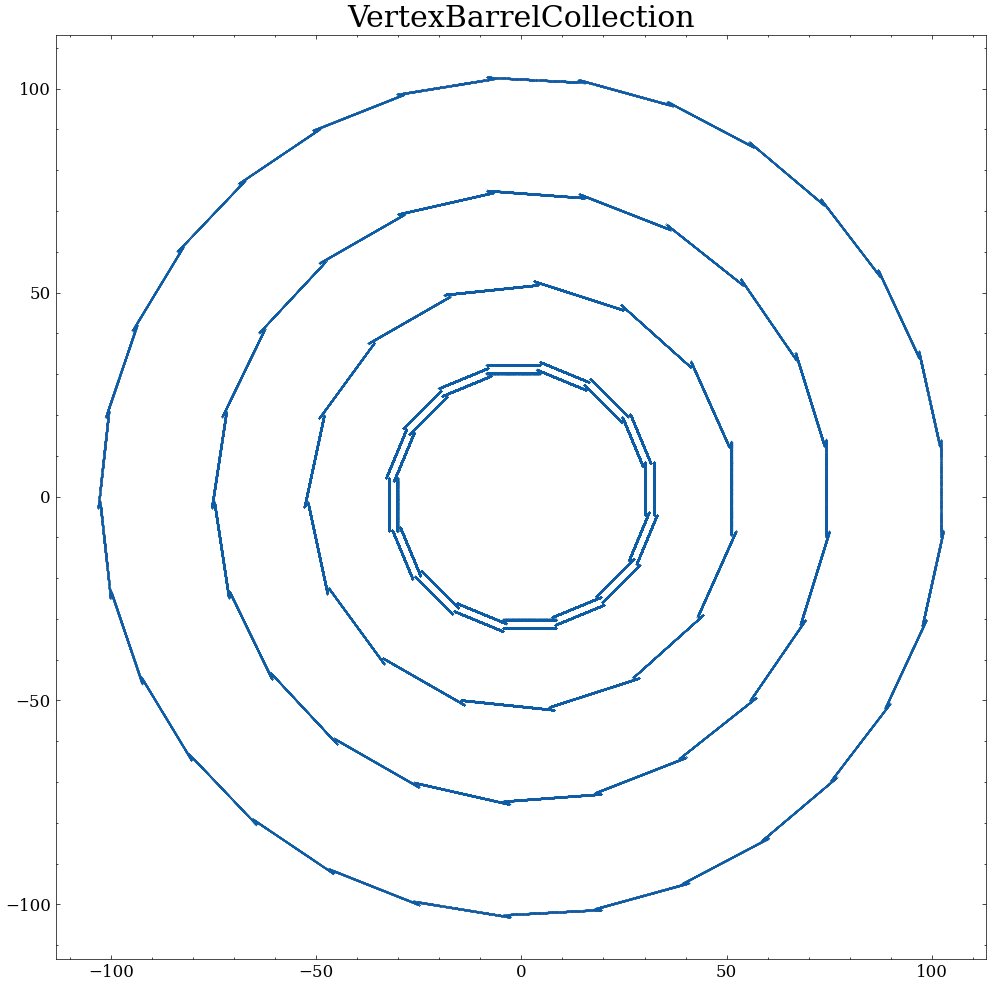

In [14]:
for col_name in data_dict.keys():
    plt.figure(figsize = (12, 12))
    plt.scatter(data_dict[col_name][:,1], data_dict[col_name][:,2], s = 0.0001)
    plt.title(col_name)
    plt.show()